<a href="https://colab.research.google.com/github/itsnothuy/AI-PACMAN/blob/master/Chapter_3%2C_Problem_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook shows how to solve Problem #4 in Chapter 3.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

I'm defining $f$ to be the unnormalized pdf.  In the problem statement, $f$ is the normalized version (it has the $c$ in it), but this way of doing things is a bit more conventional.  Note that we don't want any negative samples, so we'll assign an output of 0 to those.  This will produce a 0 in the acceptance criterion, $h$.

In [ ]:
def f(x):
  if x < 0:
    return 0
  return float(x**2*np.exp(-x))

Check to make sure the output is of the right type.  I've converted to a floating point number so that we don't get an array.

In [ ]:
f(3)

0.4480836153107755

Create a vectorized version of f, which we'll call $fv$, so that we can feed it an array of inputs all at once.  Then use it to plot the function.

In [ ]:
fv = np.vectorize(f)
x = np.linspace(0,10,200)
y = fv(x)
fig = go.Figure(data=go.Scatter(x=x, y=y))
fig.show()

Define the proposal mechanism.  The parameter delta determines the radius of the proposal interval around the current value.

In [ ]:
delta = 2
'''Use the given proposal distribution to return a sample from the neighborhood of current_state.'''
def neighbor(current_state):
  u = (delta)*(1-2*np.random.random())
  new_state = current_state + u
  return new_state


Check that it produces the right kinds of values.

In [ ]:
neighbor(5)

3.440361718934246

The following code, which runs the Metropolis Algorithm, is mostly copied from our textbook.

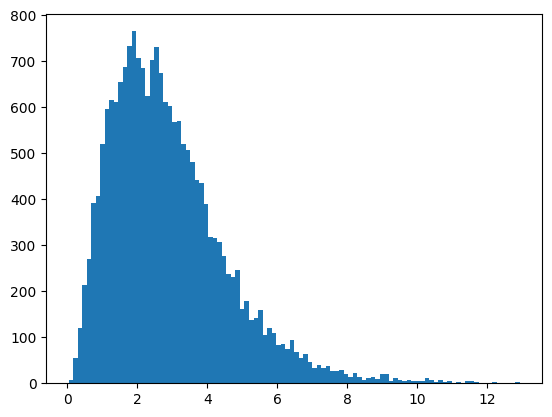

In [ ]:
nTrials = 20000;
d = [0]*nTrials
x = 1 # starting state
for i in range(nTrials):
  # do the proposal
  y = neighbor(x)
  # now do the acceptance
  h = min(1,f(y)/f(x))
  u = random.random()
  if( u < h ):
    x=y #move to y, else stay in x
  d[i] = x

plt.hist(d,bins = 100)
plt.show()



We can calculate the mean of the samples and the mean of the outputs of $f$ when evaluated at the samples.

In [ ]:
sample = np.array(d[1000:])
sample_outputs = fv(sample)
print(sample_outputs.mean())
print(sample.mean(axis=0))

0.38230212738088737
2.9012049389305927


To approximate the value of $c$, do the calculations for a histogram.  We'll also calculate the total area under the histogram.

In [ ]:
counts, bins = np.histogram(sample, bins = 100)

# Bin sizes are all the same, so just take the difference between the
# first two.
bin_size = bins[1]-bins[0]

# Calculate the total area under the histogram.
hist_area = np.sum(counts*bin_size)
hist_area

np.float64(2448.4002836598725)

Given the total area of the histogram, we can rescale the whole thing so that the total area is 1.

In [ ]:
norm_counts = counts/hist_area
norm_counts

array([0.00326744, 0.02205522, 0.04615258, 0.08536186, 0.10578336,
       0.14580949, 0.15642867, 0.20544026, 0.22994606, 0.24097367,
       0.23362193, 0.253635  , 0.26711319, 0.28304195, 0.29570328,
       0.26956377, 0.26629633, 0.23974838, 0.26752162, 0.27732393,
       0.25976145, 0.24464954, 0.23607251, 0.22300275, 0.21891845,
       0.19727166, 0.19604637, 0.18910307, 0.16949843, 0.17072372,
       0.15316123, 0.12334584, 0.1241627 , 0.1200784 , 0.10823394,
       0.09230517, 0.09026302, 0.09353046, 0.0641235 , 0.07024995,
       0.05350432, 0.0559549 , 0.06208135, 0.04247671, 0.04860316,
       0.04125142, 0.03185754, 0.03349126, 0.02940696, 0.03798399,
       0.02818167, 0.02164679, 0.02532266, 0.01919621, 0.01388662,
       0.01552034, 0.01184447, 0.01470348, 0.00857703, 0.01061918,
       0.01184447, 0.00857703, 0.00449273, 0.00898546, 0.00571802,
       0.00326744, 0.00449273, 0.00530959, 0.0040843 , 0.00735174,
       0.00735174, 0.00245058, 0.00449273, 0.00285901, 0.00204

Now find the center of each bin.  This will be useful for the next plot.

In [ ]:
bin_centers = (bins[1:]+bins[:-1])/2
bin_centers

array([ 0.09882258,  0.22768576,  0.35654893,  0.4854121 ,  0.61427528,
        0.74313845,  0.87200162,  1.00086479,  1.12972797,  1.25859114,
        1.38745431,  1.51631749,  1.64518066,  1.77404383,  1.902907  ,
        2.03177018,  2.16063335,  2.28949652,  2.4183597 ,  2.54722287,
        2.67608604,  2.80494921,  2.93381239,  3.06267556,  3.19153873,
        3.32040191,  3.44926508,  3.57812825,  3.70699142,  3.8358546 ,
        3.96471777,  4.09358094,  4.22244412,  4.35130729,  4.48017046,
        4.60903363,  4.73789681,  4.86675998,  4.99562315,  5.12448632,
        5.2533495 ,  5.38221267,  5.51107584,  5.63993902,  5.76880219,
        5.89766536,  6.02652853,  6.15539171,  6.28425488,  6.41311805,
        6.54198123,  6.6708444 ,  6.79970757,  6.92857074,  7.05743392,
        7.18629709,  7.31516026,  7.44402344,  7.57288661,  7.70174978,
        7.83061295,  7.95947613,  8.0883393 ,  8.21720247,  8.34606565,
        8.47492882,  8.60379199,  8.73265516,  8.86151834,  8.99

Let's plot the normalized histogram.

In [ ]:
fig.add_trace(go.Bar(x=bin_centers, y=norm_counts))
fig.show()

It looks as if the bars in the normalized histogram, which has an area of 1, are about half the height of the graph of $f$.  In other words, if we multiply $f$ by $\frac{1}{2}$, then we should get a curve with area 1 underneath it.  

To be a bit more precise, calculate the ratio of each bar height to the height of the graph at the bin center (so the point right above the bar on the graph of $f$).  Then average those ratios.  The result is very close to $\frac{1}{2}$.  This is our approximation for $c$.

In [ ]:
(norm_counts/fv(bin_centers)).mean()

np.float64(0.503578527583241)

A simpler approach to approximating $c$, which I'll leave it to you to figure out, is shown in the cell below.

In [ ]:
float(1/(fv(bin_centers)*bin_size).sum())

0.5001106552414439

Finally, let's plot correlations between consecutive samples.

In [ ]:
corr_fig = px.scatter(x=sample[:-1],
                      y=sample[1:],
                      title = 'Correlation between consecutive samples')
corr_fig.update_layout(xaxis_title = 'Previous sample',
                        yaxis_title = 'Current sample')
corr_fig.show()